In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
from scipy.cluster.hierarchy import linkage, cophenet
import scipy.spatial as ssp
import scipy.sparse.linalg as sla
import sklearn as sk
import plotly.express as px
import heapq
import seaborn as sns

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade --force-reinstall gensim
import gensim.downloader as api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 50.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

#NLP (to provide an initial impression of the categories)

In [ ]:
corpus = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
cats = ["church","resort","beach","park","theater","museum","mall","zoo","restaurant","pub",
        "services", "pizzeria", "hotel", "refreshments","gallery","nightclub",
        "pool", "gym","bakery","spa", "cafe", "panorama", "monument","garden"] # note some had to be renamed to fit in the corpus

dist_mat = np.zeros((len(cats),len(cats)))
for i in range(len(cats)):
  dist_mat[i,:] = corpus.distances(cats[i],cats)
dist_mat

array([[ 0.00000000e+00,  8.74361515e-01,  8.07601869e-01,
         7.39569187e-01,  7.53727376e-01,  6.61844790e-01,
         7.75634229e-01,  7.56540716e-01,  7.68463373e-01,
         7.36874044e-01,  8.64283681e-01,  7.55096674e-01,
         8.22358608e-01,  7.99625993e-01,  8.09056818e-01,
         7.96906829e-01,  9.23402190e-01,  6.95109785e-01,
         7.24293530e-01,  8.43465567e-01,  7.60724068e-01,
         9.06806469e-01,  7.14003682e-01,  7.27393746e-01],
       [ 8.74361515e-01,  0.00000000e+00,  5.72504044e-01,
         7.16127694e-01,  8.45109522e-01,  8.74957383e-01,
         7.24782228e-01,  7.89319098e-01,  6.79484963e-01,
         7.68037558e-01,  9.14413452e-01,  8.46962631e-01,
         4.20168102e-01,  9.86961126e-01,  9.53201652e-01,
         7.04273880e-01,  8.20694447e-01,  8.41326892e-01,
         8.67289901e-01,  4.70316291e-01,  7.80341983e-01,
         8.35978091e-01,  8.54617476e-01,  8.71674836e-01],
       [ 8.07601869e-01,  5.72504044e-01, -1.19209290e

<Axes: >

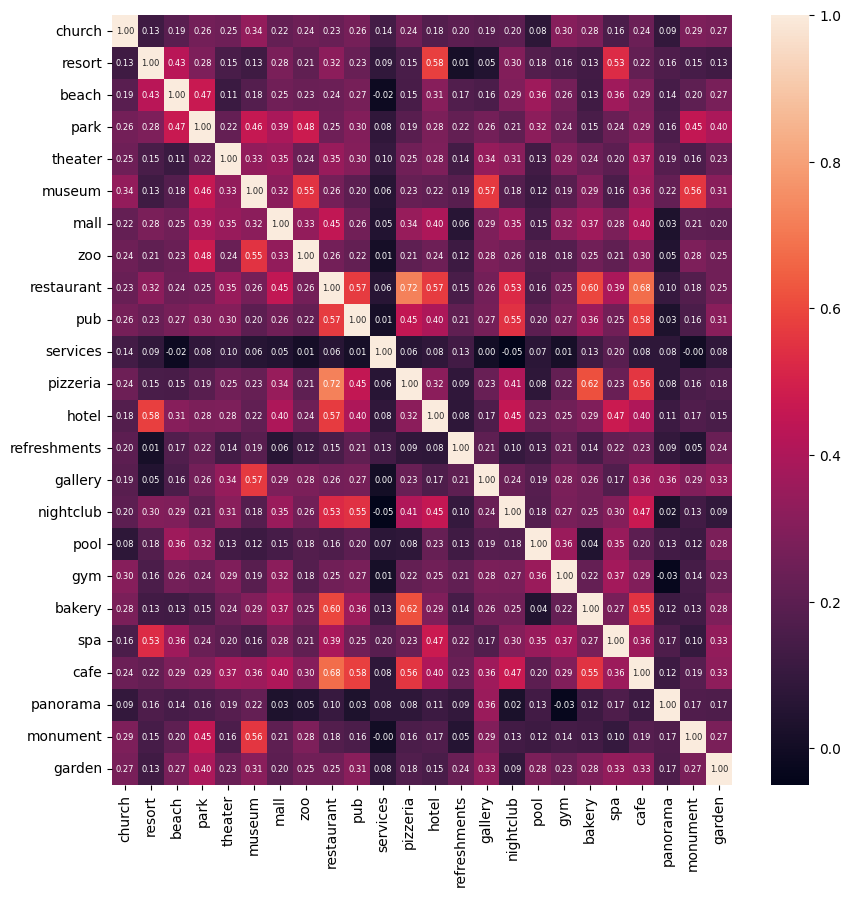

In [ ]:
fig = plt.figure(figsize=(10,10))
sns.heatmap(1-dist_mat,annot=True,annot_kws={"size":6},
            figure=fig, xticklabels=cats, yticklabels=cats, fmt=".2f")

In [ ]:
# clustering to look for decent initial groupings
n_clust = 6 # play around with this
clust = sk.cluster.AgglomerativeClustering(n_clusters=n_clust, metric="precomputed", linkage="average")
clust.fit(dist_mat)
for i in range(n_clust):
  print([cats[j] for j in range(len(cats)) if clust.labels_[j] == i])
  #print(cats[np.argwhere(clust.labels_ == i)])

['church', 'park', 'museum', 'zoo', 'gallery', 'monument', 'garden']
['pool', 'gym']
['resort', 'beach', 'theater', 'mall', 'restaurant', 'pub', 'pizzeria', 'hotel', 'nightclub', 'bakery', 'spa', 'cafe']
['services']
['refreshments']
['panorama']


#Data, MDS and Isomap

In [ ]:
# get + preprocess data
data = 'https://raw.githubusercontent.com/whosphong/DATA-STRUCTURES-AND-PLATFORMS---UAmath509/refs/heads/main/google_review_ratings.csv'
df = pd.read_csv(data)
df.drop(columns=['User', 'Unnamed: 25'], inplace=True)
column_names = ['churches', 'resorts', 'beaches', 'parks', 'theatres', 'museums', 'malls', 'zoo', 'restaurants', 'pubs_bars', 'local_services', 'burger_pizza_shops', 'hotels_other_lodgings', 'juice_bars', 'art_galleries', 'dance_clubs', 'swimming_pools', 'gyms', 'bakeries', 'beauty_spas', 'cafes', 'view_points', 'monuments', 'gardens']
df.columns = column_names
df = df[df.duplicated() == False]

In [ ]:
pd.set_option('display.max_columns',50)
df.describe()

,churches,resorts,beaches,parks,theatres,museums,malls,zoo,restaurants,pubs_bars,local_services,burger_pizza_shops,hotels_other_lodgings,juice_bars,art_galleries,dance_clubs,swimming_pools,gyms,bakeries,beauty_spas,cafes,view_points,monuments,gardens
count,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000,5451.000000
mean,1.456353,2.321123,2.488580,2.797112,2.958437,2.893300,3.351214,2.541482,3.127004,2.832352,2.549184,2.077999,2.125443,2.190083,2.205793,1.192779,0.949633,0.822060,0.969523,1.000176,0.965806,1.750116,1.531704,1.561238
std,0.827472,1.421176,1.247208,1.309352,1.338420,1.281983,1.413100,1.111569,1.356976,1.307326,1.381390,1.249012,1.406508,1.576454,1.715881,1.107408,0.973789,0.946455,1.203125,1.193227,0.928305,1.597876,1.316198,1.171704
min,0.000000,0.000000,0.000000,0.830000,1.120000,1.110000,1.120000,0.860000,0.840000,0.810000,0.780000,0.780000,0.770000,0.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.920000,1.360000,1.540000,1.730000,1.770000,1.790000,1.930000,1.620000,1.800000,1.640000,1.580000,1.290000,1.190000,1.030000,0.860000,0.690000,0.580000,0.530000,0.520000,0.540000,0.570000,0.740000,0.790000,0.880000
50%,1.340000,1.910000,2.060000,2.460000,2.670000,2.680000,3.230000,2.170000,2.800000,2.680000,2.000000,1.690000,1.610000,1.490000,1.330000,0.800000,0.740000,0.690000,0.690000,0.690000,0.760000,1.030000,1.070000,1.290000
75%,1.810000,2.690000,2.740000,4.100000,4.310000,3.835000,5.000000,3.190000,5.000000,3.525000,3.210000,2.285000,2.360000,2.740000,4.440000,1.160000,0.910000,0.840000,0.860000,0.860000,1.000000,2.070000,1.560000,1.660000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


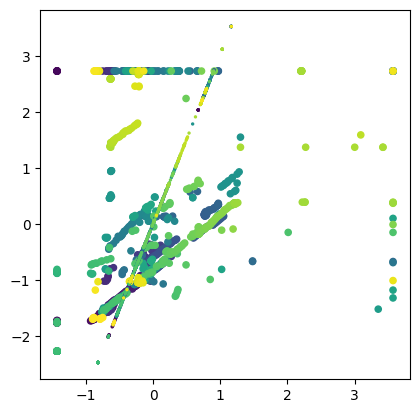

In [ ]:
# getting demonstration plots for presentation
ntest = 1000
test = np.array(df[['churches','resorts']])[0:ntest,:]

test[:,0] = test[:,0] - np.mean(test[:,0])
test[:,1] = test[:,1] - np.mean(test[:,1])

pca = sk.decomposition.PCA(n_components=1)
res = pca.fit_transform(test)


fig = plt.figure()
ax = fig.add_subplot()
ax.set_box_aspect(1)
ax.scatter(test[:,0],test[:,1],s=20,c=np.arange(ntest))
ax.scatter(*(res * pca.components_[0]).T,s=2, c=np.arange(ntest))
plt.show()

In [ ]:
def evaluate(points, labels):
  print("Silhouette: ", sk.metrics.silhouette_score(points, labels))
  print("Calinski-Harabasz: ", sk.metrics.calinski_harabasz_score(points, labels))
  print("Davies-Bouldin: ", sk.metrics.davies_bouldin_score(points, labels))

def center(arr, axis):
  return arr - np.mean(arr, axis=axis, keepdims=True)

def MDS(D, n_dims):     # input squared distance matrix, return matrix of MDS points
  B = -center(center(D, axis=0), axis=1)/2
  w, v = sla.eigsh(B, k=n_dims)
  return v @ np.diag(w)**0.5

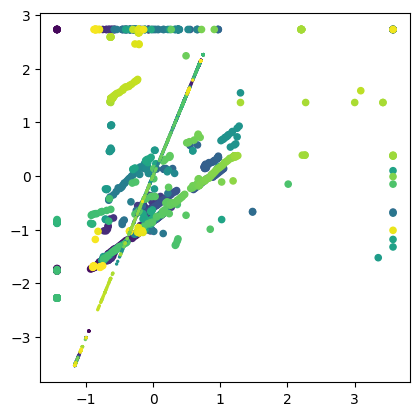

In [ ]:
n_dims = 1
X = MDS(ssp.distance_matrix(test, test, p=2), n_dims)
fig = plt.figure()
ax = fig.add_subplot()
ax.set_box_aspect(1)
ax.scatter(test[:,0],test[:,1],s=20,c=np.arange(ntest))
ax.scatter(3*X * pca.components_[0][0], 3*X * pca.components_[0][1],s=2,c=np.arange(ntest))
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 7 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.11/dist-pa

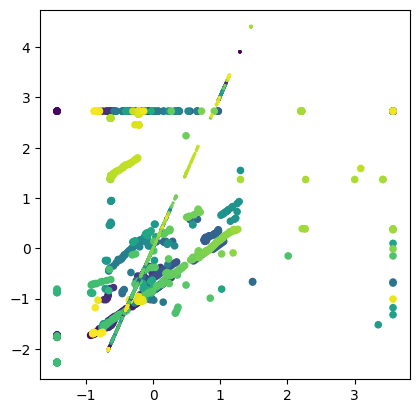

In [ ]:
embedding = sk.manifold.Isomap(n_neighbors=10, n_components=1)
X = embedding.fit_transform(test)
fig = plt.figure()
ax = fig.add_subplot()
ax.set_box_aspect(1)
ax.scatter(test[:,0],test[:,1],s=20,c=np.arange(ntest))
ax.scatter(X * pca.components_[0][0], X * pca.components_[0][1],s=2,c=np.arange(ntest))
plt.show()

In [ ]:
# grouping
entertainment = ['theatres', 'dance_clubs', 'malls']
food_travel = ['restaurants', 'pubs_bars', 'burger_pizza_shops', 'juice_bars', 'bakeries', 'cafes']
places_of_stay = ['hotels_other_lodgings', 'resorts']
historical = ['churches', 'museums', 'art_galleries', 'monuments']
nature = ['beaches', 'parks', 'zoo', 'view_points', 'gardens']
services = ['local_services', 'swimming_pools', 'gyms', 'beauty_spas']

df_category = pd.DataFrame(columns = ['entertainment', 'food_travel', 'places_of_stay', 'historical', 'nature', 'services'])

df_category['entertainment'] = df[entertainment].mean(axis = 1) # average of all entertainment
df_category['food_travel'] = df[food_travel].mean(axis = 1)
df_category['places_of_stay'] = df[places_of_stay].mean(axis = 1)
df_category['historical'] = df[historical].mean(axis = 1)
df_category['nature'] = df[nature].mean(axis = 1)
df_category['services'] = df[services].mean(axis = 1)

In [ ]:
n = 5451
df_arr = np.asarray(df_category)[:n,:]
dots = df_arr @ df_arr.T
normsqs = np.diag(dots)
n_clust = 4

In [ ]:
# euclidean distance "classical" MDS
start = time()
X2 = MDS(normsqs[:,None] + normsqs[None,:] - 2*dots, 2)
print(time()-start)
start = time()

0.9205191135406494


In [ ]:
for i in range(2,7):
  kmeans_2 = sk.cluster.KMeans(n_clusters=i, random_state=0).fit(X2)
  evaluate(X2, kmeans_2.labels_)
px.scatter(x=X2[:,0],y=X2[:,1],color=kmeans_2.labels_,width=500)

Silhouette:  0.4474005185712452
Calinski-Harabasz:  4246.944751582649
Davies-Bouldin:  0.9729140856216618
Silhouette:  0.4231686861559591
Calinski-Harabasz:  4801.391040486185
Davies-Bouldin:  0.8544480375615696
Silhouette:  0.43206825205947297
Calinski-Harabasz:  5603.11288591172
Davies-Bouldin:  0.783393617765864
Silhouette:  0.3851062727566115
Calinski-Harabasz:  5208.756962292428
Davies-Bouldin:  0.8650807247734935
Silhouette:  0.38563744262586097
Calinski-Harabasz:  5602.941652826661
Davies-Bouldin:  0.843769476568189


In [ ]:
mds_results = {}
for n_components in range(2, 6):  # From 1 to 5 components
    mds_matrix = MDS(ssp.distance_matrix(df_arr, df_arr, p=2), n_components)
    mds_results[n_components] = {
        'mds_matrix': mds_matrix
    }

# Perform clustering for a range of clusters (e.g., 2 to 10) for mds 1 to 5 results
cluster_range = range(2, 11)  # Iterating over 2 to 10 clusters
best_metrics = {n: {'Agglomerative': {}, 'KMeans': {}} for n in range(1, 6)}

# Iterating over MDS results (1D to 5D)
for n_components, mds_data in mds_results.items():
    mds_matrix = mds_data['mds_matrix']

    # Initialize lists to hold scores for both Agglomerative and KMeans
    agg_silhouette_scores = []
    kmeans_silhouette_scores = []

    agg_calinski_scores = []
    kmeans_calinski_scores = []

    agg_davies_bouldin_scores = []
    kmeans_davies_bouldin_scores = []

    # Iterating over different cluster counts
    for n_clusters in cluster_range:
        # Agglomerative Clustering
        agg_clusterer = sk.cluster.AgglomerativeClustering(n_clusters=n_clusters)
        agg_preds = agg_clusterer.fit_predict(mds_matrix)

        # Calculate the silhouette score for Agglomerative Clustering
        agg_silhouette = sk.metrics.silhouette_score(mds_matrix, agg_preds)
        agg_silhouette_scores.append(agg_silhouette)

        # Calculate the Calinski-Harabasz Index for Agglomerative Clustering
        agg_calinski = sk.metrics.calinski_harabasz_score(mds_matrix, agg_preds)
        agg_calinski_scores.append(agg_calinski)

        # Calculate the Davies-Bouldin Index for Agglomerative Clustering
        agg_davies_bouldin = sk.metrics.davies_bouldin_score(mds_matrix, agg_preds)
        agg_davies_bouldin_scores.append(agg_davies_bouldin)

        # KMeans Clustering
        kmeans_clusterer = sk.cluster.KMeans(n_clusters=n_clusters, random_state=42)
        kmeans_preds = kmeans_clusterer.fit_predict(mds_matrix)

        # Calculate the silhouette score for KMeans Clustering
        kmeans_silhouette = sk.metrics.silhouette_score(mds_matrix, kmeans_preds)
        kmeans_silhouette_scores.append(kmeans_silhouette)

        # Calculate the Calinski-Harabasz Index for KMeans Clustering
        kmeans_calinski = sk.metrics.calinski_harabasz_score(mds_matrix, kmeans_preds)
        kmeans_calinski_scores.append(kmeans_calinski)

        # Calculate the Davies-Bouldin Index for KMeans Clustering
        kmeans_davies_bouldin = sk.metrics.davies_bouldin_score(mds_matrix, kmeans_preds)
        kmeans_davies_bouldin_scores.append(kmeans_davies_bouldin)

    # Store the best metrics for Agglomerative and KMeans for the current mds type
    best_metrics[n_components]['Agglomerative'] = {
        'n_clusters': cluster_range,
        'silhouette_scores': agg_silhouette_scores,
        'calinski_scores': agg_calinski_scores,
        'davies_bouldin_scores': agg_davies_bouldin_scores
    }

    best_metrics[n_components]['KMeans'] = {
        'n_clusters': cluster_range,
        'silhouette_scores': kmeans_silhouette_scores,
        'calinski_scores': kmeans_calinski_scores,
        'davies_bouldin_scores': kmeans_davies_bouldin_scores
    }

# Find the best cluster count for each clustering method and mds type based on metrics
for n_components in range(2, 6):
    for method in ['Agglomerative', 'KMeans']:
        # Find the best silhouette score for each method
        best_silhouette = max(best_metrics[n_components][method]['silhouette_scores'])
        best_silhouette_index = best_metrics[n_components][method]['silhouette_scores'].index(best_silhouette)
        best_silhouette_clusters = best_metrics[n_components][method]['n_clusters'][best_silhouette_index]

        # Find the best Calinski-Harabasz score for each method
        best_calinski = max(best_metrics[n_components][method]['calinski_scores'])
        best_calinski_index = best_metrics[n_components][method]['calinski_scores'].index(best_calinski)
        best_calinski_clusters = best_metrics[n_components][method]['n_clusters'][best_calinski_index]

        # Find the best Davies-Bouldin score for each method (lower is better)
        best_davies_bouldin = min(best_metrics[n_components][method]['davies_bouldin_scores'])
        best_davies_bouldin_index = best_metrics[n_components][method]['davies_bouldin_scores'].index(best_davies_bouldin)
        best_davies_bouldin_clusters = best_metrics[n_components][method]['n_clusters'][best_davies_bouldin_index]

        print(f"\nBest clustering for {n_components}-D mds using {method} Clustering:")
        print(f"  Best Silhouette Score: {best_silhouette:.3f} for {best_silhouette_clusters} clusters")
        print(f"  Best Calinski-Harabasz Index: {best_calinski:.3f} for {best_calinski_clusters} clusters")
        print(f"  Best Davies-Bouldin Index: {best_davies_bouldin:.3f} for {best_davies_bouldin_clusters} clusters")
        print("-" * 50)






Best clustering for 2-D mds using Agglomerative Clustering:
  Best Silhouette Score: 0.441 for 4 clusters
  Best Calinski-Harabasz Index: 6131.867 for 4 clusters
  Best Davies-Bouldin Index: 0.736 for 5 clusters
--------------------------------------------------

Best clustering for 2-D mds using KMeans Clustering:
  Best Silhouette Score: 0.459 for 2 clusters
  Best Calinski-Harabasz Index: 6702.432 for 7 clusters
  Best Davies-Bouldin Index: 0.754 for 4 clusters
--------------------------------------------------

Best clustering for 3-D mds using Agglomerative Clustering:
  Best Silhouette Score: 0.352 for 2 clusters
  Best Calinski-Harabasz Index: 2848.494 for 2 clusters
  Best Davies-Bouldin Index: 1.034 for 7 clusters
--------------------------------------------------

Best clustering for 3-D mds using KMeans Clustering:
  Best Silhouette Score: 0.357 for 2 clusters
  Best Calinski-Harabasz Index: 3237.785 for 6 clusters
  Best Davies-Bouldin Index: 0.952 for 6 clusters
---------

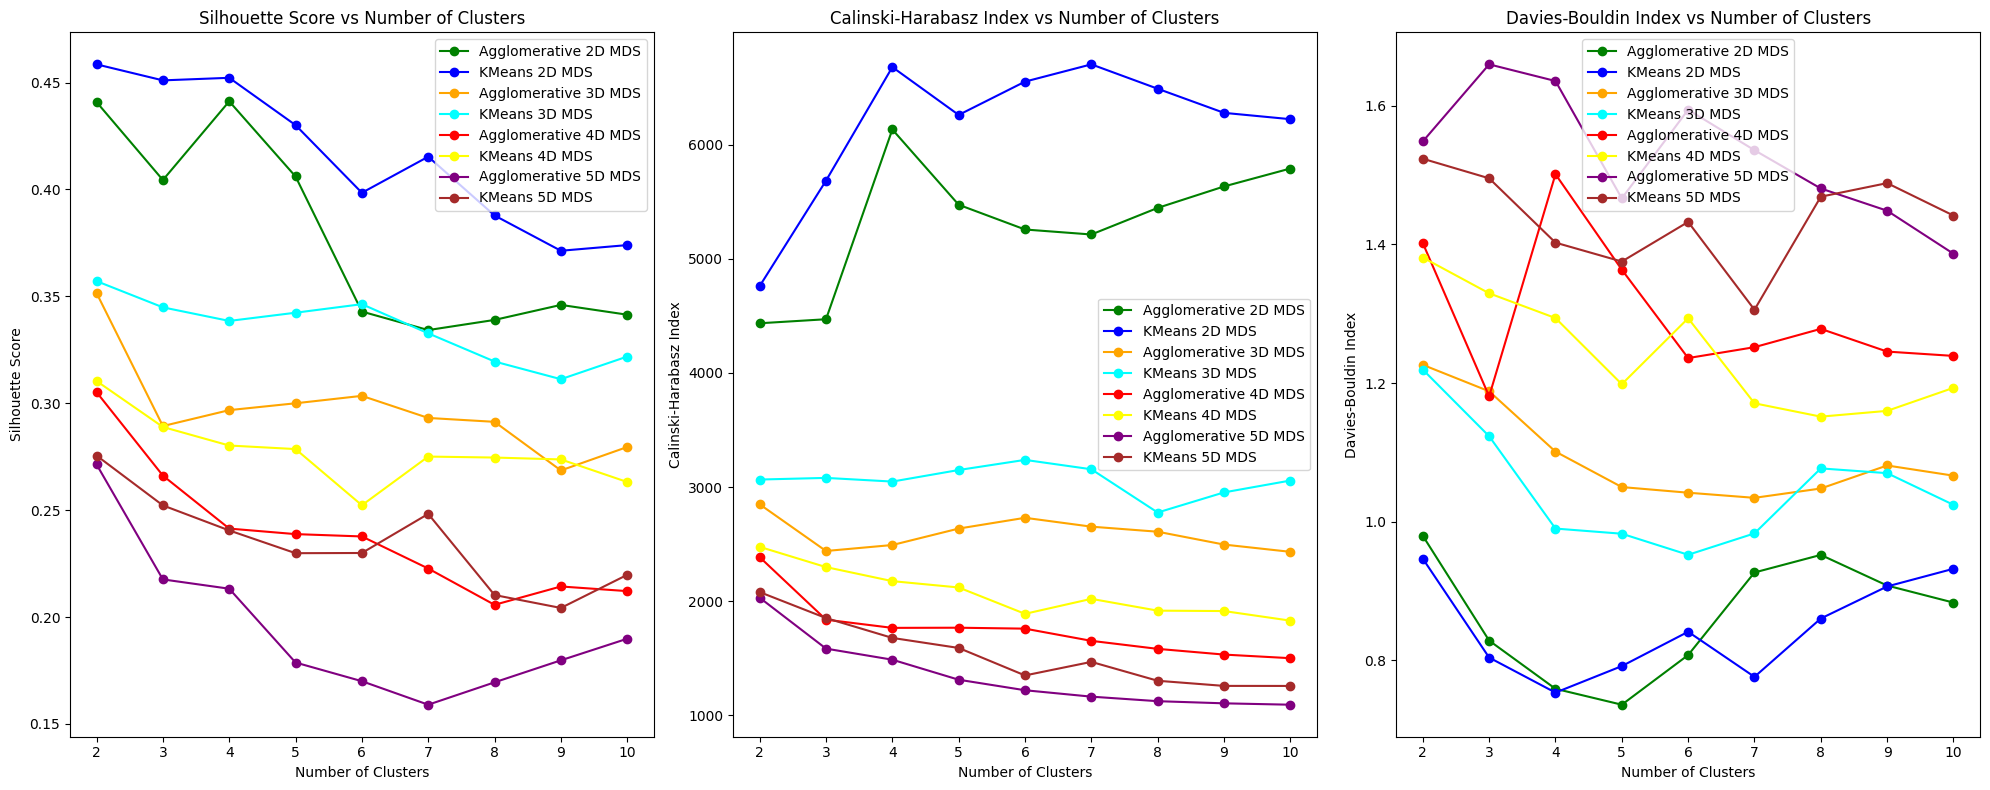

In [ ]:
# Set up the 1x3 matrix of subplots
fig, axes = plt.subplots(1,3, figsize=(20, 8))

# Define color mappings for each mds dimension
agg_colors = {2: 'green', 3: 'orange', 4: 'red', 5: 'purple'}
kmeans_colors = {2: 'blue', 3: 'cyan', 4: 'yellow', 5: 'brown'}

# Plot Silhouette Scores with different colors
for n_components in range(2, 6):
    axes[0].plot(cluster_range, best_metrics[n_components]['Agglomerative']['silhouette_scores'],
                    label=f'Agglomerative {n_components}D MDS', marker='o', color=agg_colors[n_components])
    axes[0].plot(cluster_range, best_metrics[n_components]['KMeans']['silhouette_scores'],
                    label=f'KMeans {n_components}D MDS', marker='o', color=kmeans_colors[n_components])

axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].legend()

# Plot Calinski-Harabasz Scores with different colors
for n_components in range(2, 6):
    axes[1].plot(cluster_range, best_metrics[n_components]['Agglomerative']['calinski_scores'],
                    label=f'Agglomerative {n_components}D MDS', marker='o', color=agg_colors[n_components])
    axes[1].plot(cluster_range, best_metrics[n_components]['KMeans']['calinski_scores'],
                    label=f'KMeans {n_components}D MDS', marker='o', color=kmeans_colors[n_components])

axes[1].set_title('Calinski-Harabasz Index vs Number of Clusters')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Calinski-Harabasz Index')
axes[1].legend()

# Plot Davies-Bouldin Scores with different colors
for n_components in range(2, 6):
    axes[2].plot(cluster_range, best_metrics[n_components]['Agglomerative']['davies_bouldin_scores'],
                    label=f'Agglomerative {n_components}D MDS', marker='o', color=agg_colors[n_components])
    axes[2].plot(cluster_range, best_metrics[n_components]['KMeans']['davies_bouldin_scores'],
                    label=f'KMeans {n_components}D MDS', marker='o', color=kmeans_colors[n_components])

axes[2].set_title('Davies-Bouldin Index vs Number of Clusters')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].legend()

# Adjust layout and spacing
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
def cophcorrs(X):
  for method in ["single", "complete", "average", "weighted", "centroid", "median", "ward"]:
    print(method, cophenet(linkage(X, method=method), ssp.distance.squareform(ssp.distance_matrix(X, X, p=2)))[0])

cophcorrs(X2)

single 0.4968343074817956
complete 0.6169326012154178
average 0.7489687943448267
weighted 0.5948393129889609
centroid 0.7452114856059263
median 0.6608751846497282
ward 0.707720402906204


In [ ]:
agglom_2 = sk.cluster.AgglomerativeClustering(3, linkage="average")
agglom_2.fit(X2)
evaluate(X2, agglom_2.labels_)

Silhouette:  0.44477943490057376
Calinski-Harabasz:  3682.255266035539
Davies-Bouldin:  0.7517407041795234


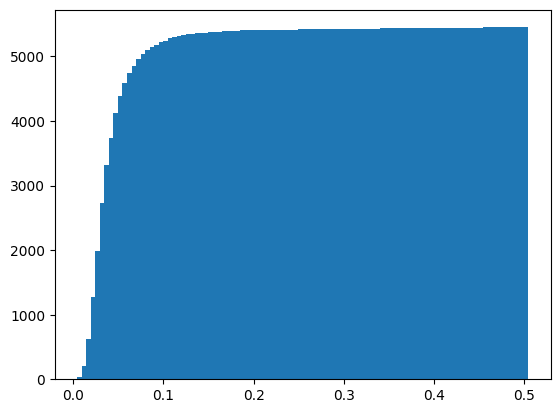

In [ ]:
# get elbow method plot to choose eps for dbscan
def pre_dbscan(X):
  neigh = sk.neighbors.NearestNeighbors(n_neighbors=10)
  neigh.fit(X)
  dist, ind = neigh.kneighbors(X)
  dist = np.mean(dist, axis=1)
  fig = plt.figure()
  ax = fig.add_subplot()
  ax.hist(dist,bins=100,cumulative=True)
  plt.show()

pre_dbscan(X2)

In [ ]:
n_dims = 2
dbscan_2 = sk.cluster.DBSCAN(eps=0.1, min_samples=10).fit(X2)
nonnoise = np.argwhere(dbscan_2.labels_ != -1).flatten()
evaluate(X2[nonnoise,:], dbscan_2.labels_[nonnoise])
fig = px.scatter(x=X2[nonnoise,0], y=X2[nonnoise,1], color=dbscan_2.labels_[nonnoise])
fig.show()

Silhouette:  0.061920472813715065
Calinski-Harabasz:  792.0925005269859
Davies-Bouldin:  0.6616432071699563


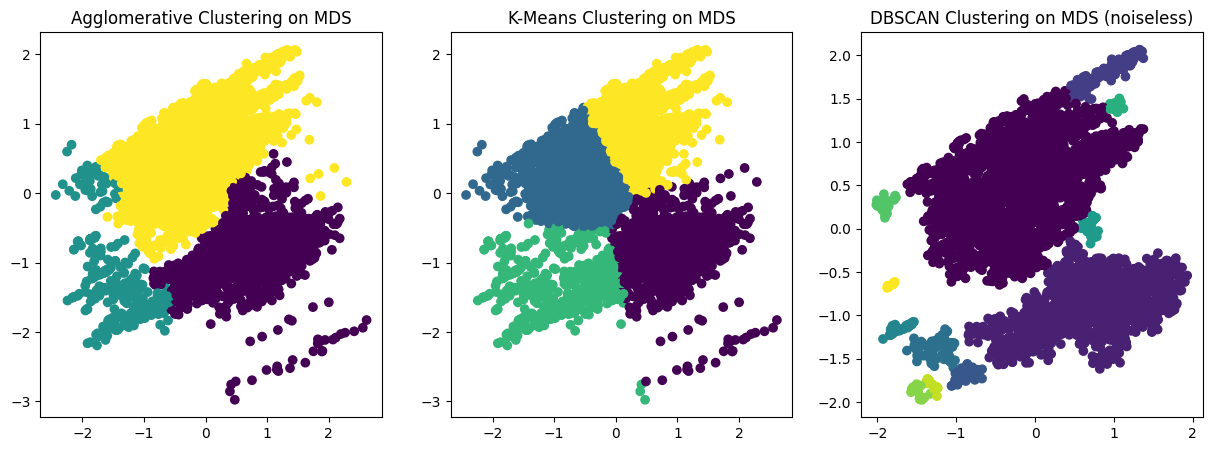

In [ ]:

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].scatter(x=X2[:,0],y=X2[:,1],c=agglom_2.labels_)
ax[1].scatter(x=X2[:,0],y=X2[:,1],c=kmeans_2.labels_)
ax[2].scatter(x=X2[nonnoise,0],y=X2[nonnoise,1],c=dbscan_2.labels_[nonnoise])
ax[0].set_title("Agglomerative Clustering on MDS")
ax[1].set_title("K-Means Clustering on MDS")
ax[2].set_title("DBSCAN Clustering on MDS (noiseless)")
fig.show()


In [ ]:
# non-metric MDS, is a bit slower than classical MDS
'''for i in range(1,10):
  embedding = sk.manifold.MDS(n_components=i, n_init = 4, max_iter = 300, metric=False)
  X = embedding.fit_transform(df_arr)
  print(embedding.stress_)
'''


embedding = sk.manifold.MDS(n_components=2, n_init = 4, max_iter = 300, metric=False)
Xnm = embedding.fit_transform(df_arr)



Silhouette:  0.4086848178034866
Calinski-Harabasz:  5507.666483950429
Davies-Bouldin:  0.7583810391624846


In [ ]:
for i in range(2,7):
  kmeans_nm = sk.cluster.KMeans(n_clusters=i, random_state=0).fit(Xnm)
  evaluate(Xnm, kmeans_nm.labels_)

Silhouette:  0.358188110932037
Calinski-Harabasz:  3307.4466966505474
Davies-Bouldin:  1.1791207540541404
Silhouette:  0.38615177488197866
Calinski-Harabasz:  4317.787987914193
Davies-Bouldin:  0.8464280807191299
Silhouette:  0.4086848178034866
Calinski-Harabasz:  5507.666483950429
Davies-Bouldin:  0.7583810391624846
Silhouette:  0.36599885588937037
Calinski-Harabasz:  5042.906028918443
Davies-Bouldin:  0.8688785388100746
Silhouette:  0.3510020148560273
Calinski-Harabasz:  4928.146084884669
Davies-Bouldin:  0.9365619480184405


single 0.2765407905641761
complete 0.6189614518588579
average 0.6345028280522946
weighted 0.6293080771862626
centroid 0.621404717125531
median 0.5972549452581356
ward 0.6257330569242076


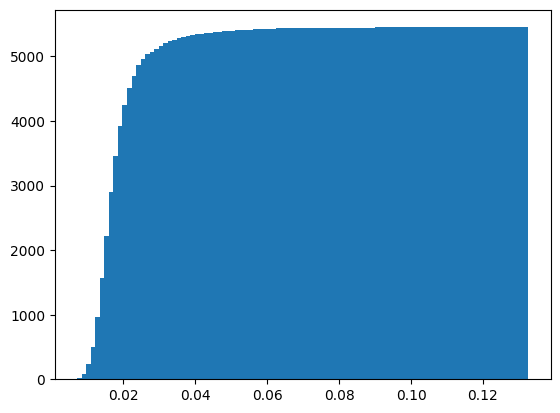

In [ ]:
cophcorrs(Xnm)
pre_dbscan(Xnm)

In [ ]:
agglom_nm = sk.cluster.AgglomerativeClustering(3, linkage="complete")
agglom_nm.fit(Xnm)
evaluate(Xnm, agglom_2.labels_)

Silhouette:  -0.0037161611475138153
Calinski-Harabasz:  0.7282124345285169
Davies-Bouldin:  111.49103130789939


In [ ]:
dbscan_nm = sk.cluster.DBSCAN(eps=0.03, min_samples=10).fit(Xnm)
nonnoise = np.argwhere(dbscan_nm.labels_ != -1).flatten()
evaluate(Xnm[nonnoise,:], dbscan_nm.labels_[nonnoise])

Silhouette:  -0.5909427516656361
Calinski-Harabasz:  18.90789496682761
Davies-Bouldin:  2.6962255244483058


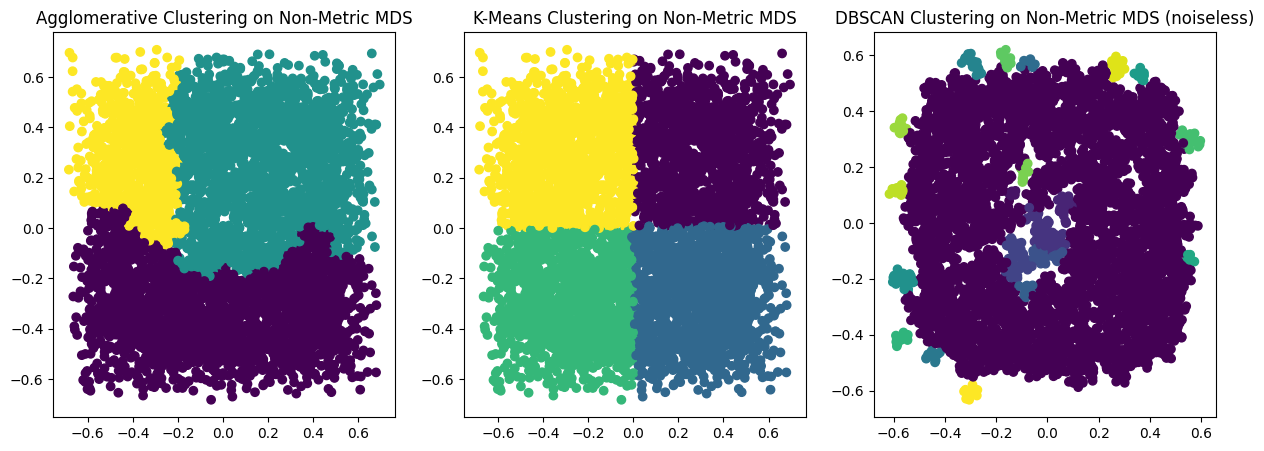

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].scatter(x=Xnm[:,0],y=Xnm[:,1],c=agglom_nm.labels_)
ax[1].scatter(x=Xnm[:,0],y=Xnm[:,1],c=kmeans_nm.labels_)
ax[2].scatter(x=Xnm[nonnoise,0],y=Xnm[nonnoise,1],c=dbscan_nm.labels_[nonnoise])
ax[0].set_title("Agglomerative Clustering on Non-Metric MDS")
ax[1].set_title("K-Means Clustering on Non-Metric MDS")
ax[2].set_title("DBSCAN Clustering on Non-Metric MDS (noiseless)")
fig.show()

In [ ]:
embedding = sk.manifold.Isomap(n_neighbors=5, n_components=2)
Xi5 = embedding.fit_transform(df_arr)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning:

The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are m

In [ ]:
for i in range(2,7):
  kmeans_i5 = sk.cluster.KMeans(n_clusters=i, random_state=0).fit(Xi5)
  evaluate(Xi5, kmeans_i5.labels_)
kmeans_i5 = sk.cluster.KMeans(n_clusters=2, random_state=0).fit(Xi5)

Silhouette:  0.5352115828409973
Calinski-Harabasz:  6876.534147630175
Davies-Bouldin:  0.7622653474810583
Silhouette:  0.4993168701404541
Calinski-Harabasz:  6741.488945770091
Davies-Bouldin:  0.7812686653343142
Silhouette:  0.49520570958784166
Calinski-Harabasz:  7954.179731301564
Davies-Bouldin:  0.7130096528245713
Silhouette:  0.4280481015520121
Calinski-Harabasz:  7179.018043960333
Davies-Bouldin:  0.8521630234029944
Silhouette:  0.4400526712311891
Calinski-Harabasz:  6869.327869417625
Davies-Bouldin:  0.7741306613654092


single 0.5099087929176825
complete 0.6252639687308038
average 0.8169866385675655
weighted 0.7557031192367781
centroid 0.8196444089800677
median 0.7696275420154994
ward 0.7325799700567939


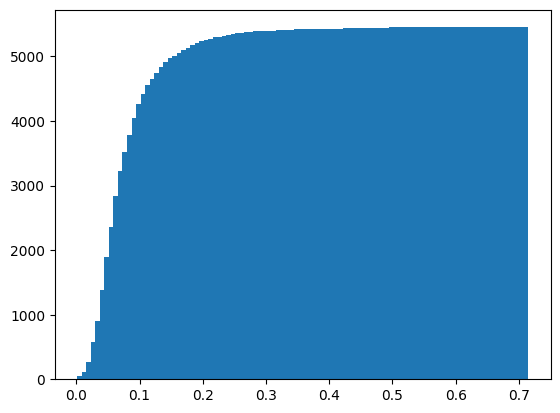

In [ ]:
cophcorrs(Xi5)
pre_dbscan(Xi5)

In [ ]:
agglom_i5 = sk.cluster.AgglomerativeClustering(3, linkage="average")
agglom_i5.fit(Xi5)
evaluate(Xi5, agglom_i5.labels_)

Silhouette:  0.5389259193768445
Calinski-Harabasz:  5840.0459665010285
Davies-Bouldin:  0.609948827999672


In [ ]:
dbscan_i5 = sk.cluster.DBSCAN(eps=0.15, min_samples=10).fit(Xi5)
nonnoise = np.argwhere(dbscan_i5.labels_ != -1).flatten()
evaluate(Xi5[nonnoise,:], dbscan_i5.labels_[nonnoise])

Silhouette:  -0.09651305680889931
Calinski-Harabasz:  754.67592432745
Davies-Bouldin:  0.6232465413446924


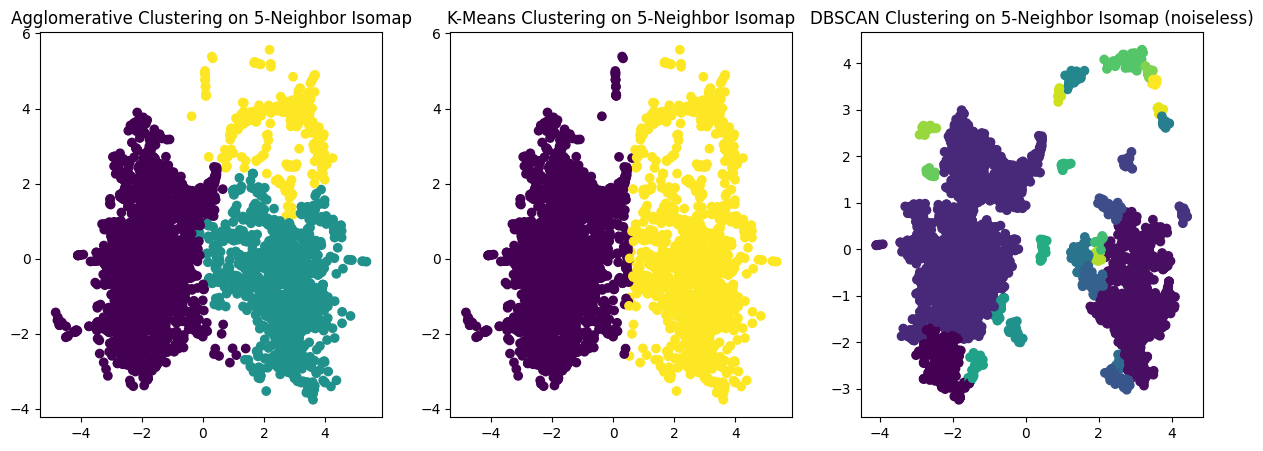

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].scatter(x=Xi5[:,0],y=Xi5[:,1],c=agglom_i5.labels_)
ax[1].scatter(x=Xi5[:,0],y=Xi5[:,1],c=kmeans_i5.labels_)
ax[2].scatter(x=Xi5[nonnoise,0],y=Xi5[nonnoise,1],c=dbscan_i5.labels_[nonnoise])
ax[0].set_title("Agglomerative Clustering on 5-Neighbor Isomap")
ax[1].set_title("K-Means Clustering on 5-Neighbor Isomap")
ax[2].set_title("DBSCAN Clustering on 5-Neighbor Isomap (noiseless)")
fig.show()

In [ ]:
# cluster counts for dbscan since there are too many to count
print(len(set(dbscan_i5.labels_)))
print(len(set(dbscan_2.labels_)))
dbscan_2.labels_

28
13


array([-1, -1, -1, ...,  1,  0,  0])

single 0.41539559401769416
complete 0.5505044287423558
average 0.6380230322935374
weighted 0.42692693761049205
centroid 0.636176669258986
median 0.36909787778799374
ward 0.5120631912950268


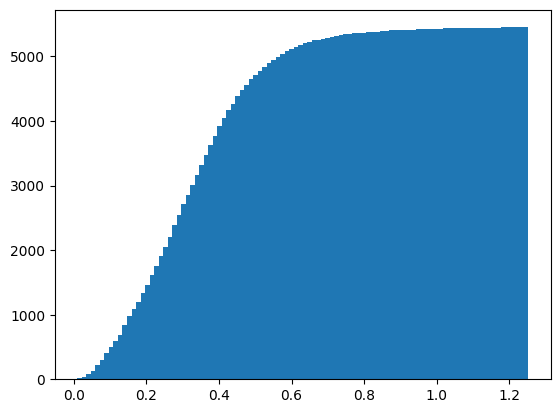

In [ ]:
cophcorrs(df_arr)
pre_dbscan(df_arr)

In [ ]:
print("K-Means on Full Category Data: ")
kmeans_1 = sk.cluster.KMeans(n_clusters=2, random_state=0).fit(df_arr)
evaluate(df_arr, kmeans_1.labels_)

print("Agglom on Full Category Data: ")
agglom_1 = sk.cluster.AgglomerativeClustering(n_clusters=2, linkage="average").fit(df_arr)
evaluate(df_arr, agglom_1.labels_)

print("DBSCAN on Full Category Data: ")
dbscan_1 = sk.cluster.DBSCAN(eps=0.5, min_samples=10).fit(Xi5)
nonnoise = np.argwhere(dbscan_1.labels_ != -1).flatten()
evaluate(df_arr[nonnoise,:], dbscan_1.labels_[nonnoise])

K-Means on Full Category Data: 
Silhouette:  0.2526036340958928
Calinski-Harabasz:  1790.145269586533
Davies-Bouldin:  1.6174270962367931
Agglom on Full Category Data: 
Silhouette:  0.3088765218628728
Calinski-Harabasz:  14.811629380502392
Davies-Bouldin:  0.8372048339688991
DBSCAN on Full Category Data: 
Silhouette:  0.16040569812194816
Calinski-Harabasz:  33.29403781409763
Davies-Bouldin:  0.796446002303084


In [ ]:
len(set(dbscan_1.labels_))

4